# Exploratory Data Analysis - Demos [5-6]

## Connect to google drive and load the dataset

In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy
from collections import Counter
from pathlib import Path

In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

In [4]:
print(fields_description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [5]:
# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')

In [6]:
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [7]:
# show eleents of the first row as ditionary
df.iloc[0].to_dict()

{'PID': 526301100,
 'MS SubClass': 20,
 'MS Zoning': 'RL',
 'Lot Frontage': 141.0,
 'Lot Area': 31770,
 'Street': 'Pave',
 'Alley': nan,
 'Lot Shape': 'IR1',
 'Land Contour': 'Lvl',
 'Utilities': 'AllPub',
 'Lot Config': 'Corner',
 'Land Slope': 'Gtl',
 'Neighborhood': 'NAmes',
 'Condition 1': 'Norm',
 'Condition 2': 'Norm',
 'Bldg Type': '1Fam',
 'House Style': '1Story',
 'Overall Qual': 6,
 'Overall Cond': 5,
 'Year Built': 1960,
 'Year Remod/Add': 1960,
 'Roof Style': 'Hip',
 'Roof Matl': 'CompShg',
 'Exterior 1st': 'BrkFace',
 'Exterior 2nd': 'Plywood',
 'Mas Vnr Type': 'Stone',
 'Mas Vnr Area': 112.0,
 'Exter Qual': 'TA',
 'Exter Cond': 'TA',
 'Foundation': 'CBlock',
 'Bsmt Qual': 'TA',
 'Bsmt Cond': 'Gd',
 'Bsmt Exposure': 'Gd',
 'BsmtFin Type 1': 'BLQ',
 'BsmtFin SF 1': 639.0,
 'BsmtFin Type 2': 'Unf',
 'BsmtFin SF 2': 0.0,
 'Bsmt Unf SF': 441.0,
 'Total Bsmt SF': 1080.0,
 'Heating': 'GasA',
 'Heating QC': 'Fa',
 'Central Air': 'Y',
 'Electrical': 'SBrkr',
 '1st Flr SF': 1656,
 

# **DEMO EDA AUTOMATION**


---


# Automation in EDA

## ydata_profiling (ex. pandas_profiling)

In [8]:
! pip install -U ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.1 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=376d20b49e5d96557974a9de208a9e67b05c70bb09672ddb22195eb34bc87a85
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [9]:
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
      Successfully uninstalled jupyter-client-6.1.12
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter-server 1.24.0
    Uninstalling jupyter-server-1.24.0:
      Successfully uninstalled jupyter-server-1.24.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.5/23.5 MB 39.2 MB/s eta 0:

In [10]:
! jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [11]:
from ydata_profiling import ProfileReport

# Load the AmesHousing dataset (replace with your dataset path)
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df_sample = df.sample(frac=0.1)  # This would sample 10% of the rows

# Generate the profile report
profile = ProfileReport(df_sample, title="AmesHousing Data Profile", explorative=True)

# To view the report in Jupyter Notebook or export to HTML
profile.to_notebook_iframe()  # To display the report inside a notebook
profile.to_file("AmesHousing_Report.html")  # To save the report as an HTML file

Output hidden; open in https://colab.research.google.com to view.

## SweetViz

In [12]:
! pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 54.0 MB/s eta 0:00:00


In [13]:
import sweetviz as sv
import pandas as pd

# Generate a SweetViz report
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df_sample = df.sample(frac=0.2)  # This would sample 20% of the rows
report = sv.analyze(df_sample)

# Display the report in a notebook or export to an HTML file
report.show_html('SweetViz_Report.html')  # Saves the report as an HTML file
report.show_notebook()

Output hidden; open in https://colab.research.google.com to view.

## D-Tale

In [14]:
!pip install -U dtale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 21.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.4 MB/s eta 0:00:00
  Created wheel for dash-colorscales: filename=

In [35]:
import pandas as pd
import dtale
import dtale.app as dtale_app

df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df_sample = df.sample(frac=0.2)  # This would sample 20% of the rows

dtale_app.USE_COLAB = True
dtale.show(df_sample, notebook=True)

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2j70qcp7xxk-496ff2e9c6d22116-40000-colab.googleusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2j70qcp7xxk-496ff2e9c6d22116-40000-colab.googleusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2j70qcp7xxk-496ff2e9c6d22116-40000-colab.googleusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-u

https://2j70qcp7xxk-496ff2e9c6d22116-40000-colab.googleusercontent.com/dtale/main/9

# **DEMO VISUALIZATION TOOLS**


---



# Visualization Tools:

## ggplot (Python)

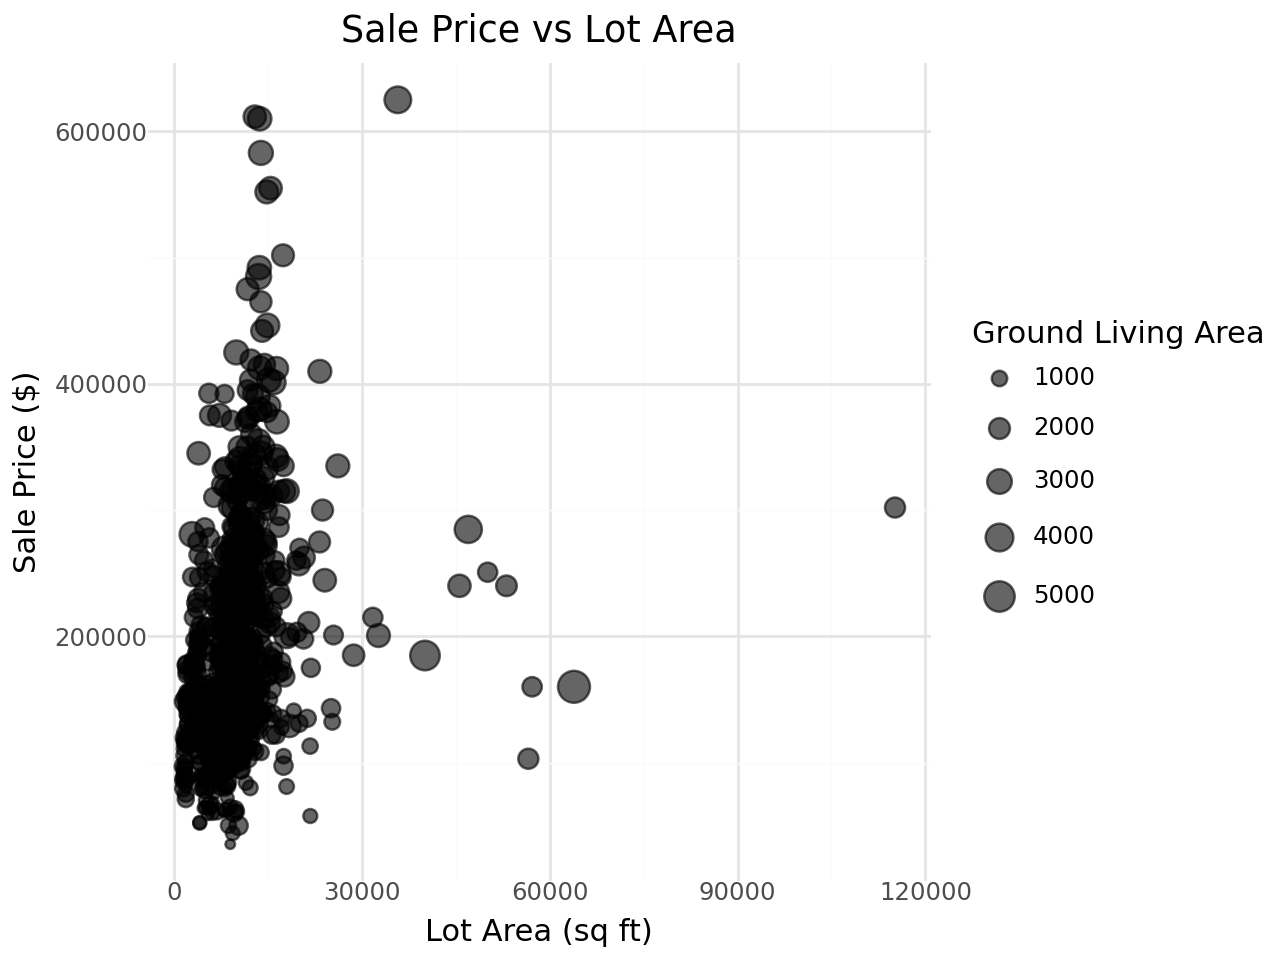

In [16]:
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_point, facet_wrap, scale_color_gradient, labs, theme_minimal


# Strip whitespace from column names if necessary
df.columns = df.columns.str.strip()

# Remove rows where 'YearBuilt' is missing to avoid facetting errors
df_cleaned = df.dropna(subset=['Year Built'])

# Take a subset of the data for faster rendering if needed (e.g., 1000 samples)
df_subset = df_cleaned.sample(1000, random_state=42)

# Create the plot
p = (ggplot(df_subset, aes(x='Lot Area', y='SalePrice', size='Gr Liv Area'))
     + geom_point(alpha=0.6)  # Add points with transparency
     + scale_color_gradient(low="blue", high="red")  # Set color gradient based on 'OverallQual'
     + labs(title="Sale Price vs Lot Area", x="Lot Area (sq ft)", y="Sale Price ($)",
            size="Ground Living Area", color="Overall Quality")  # Add labels and title
     + theme_minimal()  # Use a minimal theme
)

# Show the plot using plot.show() instead of print(p)
p.show()


## Plotly

In [17]:
import plotly.express as px
import pandas as pd

# Scatter plot of Sale Price vs Number of Garage Cars
fig = px.scatter(df, x="Garage Cars", y="SalePrice",
                 title="Scatter Plot: Sale Price vs Number of Garage Cars")
fig.show()

In [18]:
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df.columns

Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

In [19]:
# Box plot to visualize distribution of Sale Price by number of garage cars
fig = px.box(df, x="Garage Cars", y="SalePrice",
             title="Box Plot: Sale Price Distribution by Garage Cars")
fig.show()

In [20]:
# Sample DataFrame
df1 = pd.DataFrame({
    "Neighborhood": ["A", "B", "C", "D"],
    "Average Sale Price": [250000, 300000, 350000, 400000],
    "Std Dev": [20000, 25000, 30000, 35000]
})

# Bar plot with hover text for standard deviation
fig = px.bar(df1, x="Neighborhood", y="Average Sale Price",
             title="Bar Plot: Average Sale Price by Neighborhood",
             hover_data=["Std Dev"])
fig.show()

In [21]:
import plotly.express as px
import pandas as pd

# Sample DataFrame with 3D data
df1 = pd.DataFrame({
    "Garage Cars": [1, 2, 3, 1, 2, 2, 3, 3],
    "Lot Area": [10000, 15000, 20000, 9000, 14000, 16000, 25000, 22000],
    "Sale Price": [200000, 350000, 400000, 210000, 360000, 340000, 420000, 410000]
})

# 3D scatter plot
fig = px.scatter_3d(df1, x="Garage Cars", y="Lot Area", z="Sale Price",
                    title="3D Scatter Plot: Garage Cars vs Lot Area vs Sale Price")
fig.show()

In [22]:
import plotly.express as px
import pandas as pd

# Sample DataFrame
df1 = pd.DataFrame({
    "Neighborhood": ["A", "B", "C", "D"],
    "Sale Price": [250000, 300000, 350000, 400000]
})

# Pie chart
fig = px.pie(df1, names="Neighborhood", values="Sale Price",
             title="Pie Chart: Sale Price Distribution by Neighborhood")
fig.show()

## Bokeh

In [23]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import pandas as pd

# Display Bokeh plots in the notebook
output_notebook()

# Sample DataFrame
df1 = pd.DataFrame({
    "Garage Cars": [1, 2, 3, 1, 2, 2, 3, 3],
    "Sale Price": [200000, 350000, 400000, 210000, 360000, 340000, 420000, 410000]
})

# Create a scatter plot
p = figure(title="Scatter Plot: Sale Price vs Number of Garage Cars",
           x_axis_label='Number of Garage Cars', y_axis_label='Sale Price ($)')
p.scatter(df1["Garage Cars"], df1["Sale Price"], size=10, color="navy", alpha=0.6)

# Show the plot
show(p)

In [24]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Ensure output in notebook (for Jupyter Notebooks)
output_notebook()

# Load your dataset (replace with the actual path to your dataset)
# df = pd.read_csv('housing_data.csv')  # Uncomment and use your actual dataset

# Strip whitespace from column names if necessary
df.columns = df.columns.str.strip()

# Sample a smaller dataset for faster rendering (optional)
df_subset = df.sample(200, random_state=42)  # Adjust the number as needed

# Set x, y, and sizes from the dataset
x = df_subset['Lot Area']
y = df_subset['SalePrice']
sizes = df_subset['Gr Liv Area'] / 100  # Scale down for better visualization

# Create a figure object
p = figure(title="Housing Data: Lot Area vs Sale Price",
           x_axis_label='Lot Area (sq ft)',
           y_axis_label='Sale Price ($)',
           tools="pan, wheel_zoom, box_zoom, reset, save")

# Add circle glyphs to the figure, with sizes based on 'Gr Liv Area'
p.circle(x, y, size=sizes, color="navy", alpha=0.6)

# Display the plot
show(p)


In [25]:
from bokeh.plotting import figure, show
from bokeh.models import HoverTool
import pandas as pd

# Sample DataFrame
df1 = pd.DataFrame({
    "Neighborhood": ["A", "B", "C", "D"],
    "Average Sale Price": [250000, 300000, 350000, 400000],
    "Std Dev": [20000, 25000, 30000, 35000]
})

# Create a bar plot
p = figure(x_range=df1["Neighborhood"], title="Bar Plot: Average Sale Price by Neighborhood",
           y_axis_label="Average Sale Price ($)")

# Add bars
p.vbar(x=df1["Neighborhood"], top=df1["Average Sale Price"], width=0.9, color="skyblue")

# Add hover tool
hover = HoverTool()
hover.tooltips = [("Neighborhood", "@x"), ("Average Sale Price", "@top"), ("Std Dev", "@y")]
p.add_tools(hover)

# Show the plot
show(p)


**[!]** Bokeh does not support 3D Scatter Plot or Pie charts

## Altair

In [26]:
import pandas as pd
import altair as alt
import warnings
# Suppress the specific FutureWarning from pandas/altair
warnings.filterwarnings('ignore', category=FutureWarning)

# Load your dataset (replace with the actual path to your dataset)
# df = pd.read_csv('data.csv')  # Uncomment and use your actual dataset

# Strip whitespace from column names if necessary
df.columns = df.columns.str.strip()

# Take a subset of the data for faster rendering (optional)
df_subset = df.sample(500, random_state=42)  # Adjust the sample size as needed

# Create an Altair chart with increased width and height
chart = alt.Chart(df_subset).mark_circle(size=60).encode(
    x=alt.X('Lot Area:Q', title='Lot Area (sq ft)'),
    y=alt.Y('SalePrice:Q', title='Sale Price ($)'),
    size=alt.Size('Gr Liv Area:Q', title='Ground Living Area'),
    color=alt.Color('Overall Qual:N', title='Overall Quality'),  # Color by Overall Quality if available
    tooltip=['Lot Area', 'SalePrice', 'Gr Liv Area', 'Overall Qual'],  # Add more fields as needed
).properties(
    width=800,  # Adjust the width as desired
    height=600  # Adjust the height as desired
).interactive()  # Enable interactivity like zooming and panning

# Display the chart
chart

alt.Chart(...)

In [27]:
import altair as alt
import pandas as pd
import warnings
# Suppress the specific FutureWarning from pandas/altair
warnings.filterwarnings('ignore', category=FutureWarning)

# Create a slider for bin size using `alt.param`
slider = alt.binding_range(min=1, max=100, step=5, name='Bin Size: ')
bin_size = 50

# Create a binning transformation with a dynamic bin size
hist = alt.Chart(df).mark_bar().encode(
    x=alt.X('binned_SalePrice:Q', title="Sale Price ($)"),
    y=alt.Y('count()', title='Count')
).transform_bin(
    'binned_SalePrice', field='SalePrice', bin=alt.Bin(maxbins=bin_size)
).properties(
    width=600,
    height=400
).interactive()

# Display the chart
hist


Output hidden; open in https://colab.research.google.com to view.